# PHM 2025 — Implementazione paper-compliant

Implementazione allineata al paper:
**Maintenance Service Events Prediction Modeling of Aircraft Gas Turbine Engines**.

## Obiettivo
Predire i cicli rimanenti ai tre eventi di manutenzione:
- `Cycles_to_HPT_SV`
- `Cycles_to_HPC_SV`
- `Cycles_to_WW`

## Scelte metodologiche (fedeli al paper)
1. Data cleaning robusto (duplicati, outlier IQR, interpolazione snapshot-wise)
2. Virtual sensors (`P25`, `T5`) con regressione lineare con interaction terms
3. Feature engineering domain-informed (pressure ratios, temp drops, efficiency proxies)
4. Aggregazione snapshot→cycle con statistiche (`mean/std/min/max/range/median/rms`)
5. Feature selection con soglia di varianza `< 0.01`
6. Health Indicators (HPT/HPC) come combinazioni pesate normalizzate
7. Feature binaria di recovery HI per supportare WW/HPC
8. Event-specific models:
   - HPT: ANN regressor
   - HPC: LSTM con custom time-weighted loss
   - WW: LSTM con custom time-weighted loss
9. Profile registration dei file validation/test usando continuità HI

In [ ]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Any
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from scipy import stats
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import ElasticNetCV, LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from torch.utils.data import DataLoader, Dataset

from tools import utils as u


warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [ ]:
# COSTANTI

RAW_SENSOR_COLS = [
    "Sensed_Altitude",
    "Sensed_Mach",
    "Sensed_Pamb",
    "Sensed_Pt2",
    "Sensed_TAT",
    "Sensed_WFuel",
    "Sensed_VAFN",
    "Sensed_VBV",
    "Sensed_Fan_Speed",
    "Sensed_Core_Speed",
    "Sensed_T25",
    "Sensed_T3",
    "Sensed_Ps3",
    "Sensed_T45",
    "Sensed_P25",
    "Sensed_T5",
]

VIRTUAL_SENSOR_TARGETS = ["Sensed_P25", "Sensed_T5"]

TARGET_COLS = ["Cycles_to_HPT_SV", "Cycles_to_HPC_SV", "Cycles_to_WW"]
CUMULATIVE_COLS = ["Cumulative_HPT_SVs", "Cumulative_HPC_SVs", "Cumulative_WWs"]

GAMMA_AIR = 1.4

In [ ]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(42)


def detect_cycle_column(df: pd.DataFrame) -> str:
    if "Cycles_Since_New" in df.columns:
        return "Cycles_Since_New"
    if "Cycles" in df.columns:
        return "Cycles"
    raise ValueError("Colonna ciclo non trovata. Atteso 'Cycles_Since_New' o 'Cycles'.")


def safe_div(num: pd.Series | np.ndarray | float, den: pd.Series | np.ndarray | float) -> Any:
    with np.errstate(divide="ignore", invalid="ignore"):
        out = np.divide(num, den)
    if isinstance(out, np.ndarray):
        out[~np.isfinite(out)] = np.nan
        return out
    return out.replace([np.inf, -np.inf], np.nan)


def rmse_np(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def time_weighted_error(y_true: np.ndarray, y_pred: np.ndarray, alpha: float = 0.02, beta: float = 1.0) -> np.ndarray:
    err = y_pred - y_true
    weight = np.where(err >= 0, 2.0 / (1.0 + alpha * y_true), 1.0 / (1.0 + alpha * y_true))
    return weight * (err**2) * beta


def twe_score(y_true: np.ndarray, y_pred: np.ndarray, alpha: float = 0.02, beta: float = 1.0) -> float:
    return float(np.mean(time_weighted_error(y_true, y_pred, alpha=alpha, beta=beta)))

## 1) Data cleaning

Pulizia coerente con il paper:
- rimozione duplicati
- gestione altitudini negative
- outlier removal IQR per gruppo (`ESN`, `Snapshot`)
- interpolazione snapshot-wise e fill per ESN

In [ ]:
def remove_outliers_iqr_grouped(
    df: pd.DataFrame,
    sensor_cols: list[str],
    group_cols: tuple[str, ...] = ("ESN", "Snapshot"),
    k: float = 1.5,
) -> pd.DataFrame:
    out = df.copy()
    valid_group_cols = [c for c in group_cols if c in out.columns]
    if not valid_group_cols:
        valid_group_cols = ["ESN"] if "ESN" in out.columns else []
    if not valid_group_cols:
        return out

    for sensor in sensor_cols:
        if sensor not in out.columns:
            continue

        def _mask_iqr(series: pd.Series) -> pd.Series:
            q1 = series.quantile(0.25)
            q3 = series.quantile(0.75)
            iqr = q3 - q1
            if pd.isna(iqr) or iqr == 0:
                return series
            low = q1 - k * iqr
            high = q3 + k * iqr
            return series.mask((series < low) | (series > high))

        out[sensor] = out.groupby(valid_group_cols, dropna=False)[sensor].transform(_mask_iqr)

    return out


def interpolate_snapshotwise(df: pd.DataFrame, sensor_cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    if "ESN" not in out.columns:
        return out

    if "Snapshot" in out.columns:
        group_cols = ["ESN", "Snapshot"]
    else:
        group_cols = ["ESN"]

    for sensor in sensor_cols:
        if sensor not in out.columns:
            continue

        out[sensor] = out.groupby(group_cols, dropna=False)[sensor].transform(
            lambda s: s.interpolate(method="linear", limit_direction="both")
        )
        out[sensor] = out.groupby(["ESN"], dropna=False)[sensor].transform(lambda s: s.ffill().bfill())

    return out


def preprocess_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    out = out.drop_duplicates().reset_index(drop=True)

    if "Sensed_Altitude" in out.columns:
        out.loc[out["Sensed_Altitude"] < 0, "Sensed_Altitude"] = 0.0

    cycle_col = detect_cycle_column(out)
    sort_cols = ["ESN", cycle_col] + (["Snapshot"] if "Snapshot" in out.columns else [])
    out = out.sort_values(sort_cols).reset_index(drop=True)

    sensor_cols = [c for c in RAW_SENSOR_COLS if c in out.columns]
    out = remove_outliers_iqr_grouped(out, sensor_cols=sensor_cols, group_cols=("ESN", "Snapshot"), k=1.5)
    out = interpolate_snapshotwise(out, sensor_cols=sensor_cols)

    return out


def preprocess_file_list(file_list: list[pd.DataFrame]) -> list[pd.DataFrame]:
    return [preprocess_dataframe(df) for df in file_list]

## 2) Virtual sensor modeling (`P25`, `T5`)

Nel paper i segnali `P25` e `T5` mancanti in validation/test sono stimati
con modelli lineari con termini di interazione.

In [ ]:
VIRTUAL_SENSOR_FEATURE_CANDIDATES = [
    "Snapshot",
    "Sensed_Altitude",
    "Sensed_Mach",
    "Sensed_Pamb",
    "Sensed_Pt2",
    "Sensed_TAT",
    "Sensed_WFuel",
    "Sensed_VAFN",
    "Sensed_VBV",
    "Sensed_Fan_Speed",
    "Sensed_Core_Speed",
    "Sensed_T25",
    "Sensed_T3",
    "Sensed_Ps3",
    "Sensed_T45",
]


def train_virtual_sensor_models(train_df: pd.DataFrame) -> tuple[dict[str, dict[str, Any]], pd.DataFrame]:
    models: dict[str, dict[str, Any]] = {}
    metrics_rows: list[dict[str, float | str]] = []

    for target in VIRTUAL_SENSOR_TARGETS:
        if target not in train_df.columns:
            continue

        feat_cols = [c for c in VIRTUAL_SENSOR_FEATURE_CANDIDATES if c in train_df.columns and c != target]
        if not feat_cols:
            continue

        tmp = train_df[feat_cols + [target]].dropna().copy()
        if len(tmp) < 500:
            continue

        X = tmp[feat_cols]
        y = tmp[target]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, shuffle=True
        )

        model = Pipeline(
            steps=[
                ("scale", StandardScaler()),
                (
                    "interactions",
                    PolynomialFeatures(degree=2, interaction_only=True, include_bias=False),
                ),
                ("reg", LinearRegression()),
            ]
        )

        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        rmse = rmse_np(y_test.values, pred)
        mae = float(mean_absolute_error(y_test.values, pred))
        r2 = float(r2_score(y_test.values, pred))

        models[target] = {
            "model": model,
            "feature_cols": feat_cols,
            "rmse": rmse,
            "mae": mae,
            "r2": r2,
        }

        metrics_rows.append({"target": target, "rmse": rmse, "mae": mae, "r2": r2})

    metrics_df = pd.DataFrame(metrics_rows)
    return models, metrics_df


def apply_virtual_sensor_models(df: pd.DataFrame, virtual_models: dict[str, dict[str, Any]]) -> pd.DataFrame:
    out = df.copy()
    for target, bundle in virtual_models.items():
        feat_cols: list[str] = bundle["feature_cols"]
        model: Pipeline = bundle["model"]

        for col in feat_cols:
            if col not in out.columns:
                out[col] = 0.0

        X = out[feat_cols].copy().ffill().bfill().fillna(0.0)
        pred = model.predict(X)

        if target not in out.columns:
            out[target] = pred
        else:
            out[target] = out[target].fillna(pd.Series(pred, index=out.index))

    return out


def apply_virtual_sensor_models_to_list(
    file_list: list[pd.DataFrame], virtual_models: dict[str, dict[str, Any]]
) -> list[pd.DataFrame]:
    return [apply_virtual_sensor_models(df, virtual_models) for df in file_list]

## 3) Domain-informed feature engineering

In [ ]:
ENGINEERED_FEATURES = [
    # Pressure ratios
    "PR_HPC",
    "PR_LPC",
    "PR_FAN",
    "PR_COMPRESSOR",
    "PR_ENGINE_OVERALL",
    # Relative temperature drops
    "TEMP_DROP_HPT_REL",
    "TEMP_DROP_LPT_REL",
    "TEMP_DROP_TURBINE_REL",
    # Efficiency proxies
    "EFF_THERMAL_PROXY",
    "EFF_COMBUSTOR_PROXY",
    "EFF_COMP_THERMAL_PROXY",
    "SPECIFIC_FUEL_CONS_PROXY",
    "SPECIFIC_POWER_PROXY",
    # Corrected speeds
    "CORR_FAN_SPEED",
    "CORR_CORE_SPEED",
]


def add_domain_features(df: pd.DataFrame, gamma_air: float = GAMMA_AIR) -> pd.DataFrame:
    out = df.copy()

    out["PR_HPC"] = safe_div(out.get("Sensed_Ps3"), out.get("Sensed_P25"))
    out["PR_LPC"] = safe_div(out.get("Sensed_P25"), out.get("Sensed_Pt2"))
    out["PR_FAN"] = safe_div(out.get("Sensed_Pt2"), out.get("Sensed_Pamb"))
    out["PR_COMPRESSOR"] = safe_div(out.get("Sensed_Ps3"), out.get("Sensed_Pt2"))
    out["PR_ENGINE_OVERALL"] = safe_div(out.get("Sensed_Ps3"), out.get("Sensed_Pamb"))

    out["TEMP_DROP_HPT_REL"] = safe_div(
        out.get("Sensed_T45") - out.get("Sensed_T3"), out.get("Sensed_T3")
    )
    out["TEMP_DROP_LPT_REL"] = safe_div(
        out.get("Sensed_T5") - out.get("Sensed_T45"), out.get("Sensed_T45")
    )
    out["TEMP_DROP_TURBINE_REL"] = safe_div(
        out.get("Sensed_T5") - out.get("Sensed_T3"), out.get("Sensed_T3")
    )

    out["EFF_THERMAL_PROXY"] = safe_div(
        out.get("Sensed_T5") - out.get("Sensed_TAT"), out.get("Sensed_T3") - out.get("Sensed_TAT")
    )
    out["EFF_COMBUSTOR_PROXY"] = safe_div(
        out.get("Sensed_T45") - out.get("Sensed_T25"), out.get("Sensed_T25") - out.get("Sensed_TAT")
    )

    opr = out["PR_ENGINE_OVERALL"].clip(lower=1e-8)
    opr_term = np.power(opr, (gamma_air - 1.0) / gamma_air)
    out["EFF_COMP_THERMAL_PROXY"] = safe_div(1.0, (1.0 - opr_term))

    out["SPECIFIC_FUEL_CONS_PROXY"] = safe_div(
        out.get("Sensed_WFuel"), out.get("Sensed_T5") - out.get("Sensed_TAT")
    )
    out["SPECIFIC_POWER_PROXY"] = out.get("Sensed_T5") * out.get("Sensed_Mach")

    sqrt_tat = np.sqrt(out.get("Sensed_TAT").clip(lower=1e-8))
    out["CORR_FAN_SPEED"] = safe_div(out.get("Sensed_Fan_Speed"), sqrt_tat)
    out["CORR_CORE_SPEED"] = safe_div(out.get("Sensed_Core_Speed"), sqrt_tat)

    out = out.replace([np.inf, -np.inf], np.nan)
    return out

## 4) Aggregazione snapshot→cycle e feature selection

In [ ]:
def aggregate_cycle_features(df: pd.DataFrame, feature_inputs: list[str]) -> pd.DataFrame:
    cycle_col = detect_cycle_column(df)

    valid_feature_inputs = [c for c in feature_inputs if c in df.columns]
    if not valid_feature_inputs:
        raise ValueError("Nessuna feature disponibile per l'aggregazione cycle-level")

    grp = df.groupby(["ESN", cycle_col], sort=True, as_index=False)

    stats_df = grp[valid_feature_inputs].agg(["mean", "std", "min", "max", "median"])
    stats_df.columns = [
        f"{col}_{stat}" if stat else col
        for col, stat in stats_df.columns.to_flat_index()
    ]
    stats_df = stats_df.reset_index().rename(columns={cycle_col: "Cycle"})

    # Range = max - min
    for col in valid_feature_inputs:
        max_col = f"{col}_max"
        min_col = f"{col}_min"
        if max_col in stats_df.columns and min_col in stats_df.columns:
            stats_df[f"{col}_range"] = stats_df[max_col] - stats_df[min_col]

    # RMS
    rms_df = (
        df.groupby(["ESN", cycle_col], sort=True)[valid_feature_inputs]
        .apply(lambda x: np.sqrt((x**2).mean()))
        .reset_index()
        .rename(columns={cycle_col: "Cycle"})
    )
    rms_df = rms_df.rename(columns={c: f"{c}_rms" for c in valid_feature_inputs})

    out = stats_df.merge(rms_df, on=["ESN", "Cycle"], how="left")

    # Etichette / metadati event-based (solo training)
    meta_cols = [c for c in TARGET_COLS + CUMULATIVE_COLS if c in df.columns]
    if meta_cols:
        meta_df = (
            df.groupby(["ESN", cycle_col], sort=True)[meta_cols]
            .last()
            .reset_index()
            .rename(columns={cycle_col: "Cycle"})
        )
        out = out.merge(meta_df, on=["ESN", "Cycle"], how="left")

    out = out.sort_values(["ESN", "Cycle"]).reset_index(drop=True)
    return out


def remove_artificial_tail(cycle_df: pd.DataFrame, tail_cycles: int = 200) -> pd.DataFrame:
    """
    Nel paper sono stati rimossi i cicli finali artificialmente troncati a 20k.
    Qui rimuoviamo gli ultimi `tail_cycles` per ESN.
    """
    parts = []
    for _, g in cycle_df.groupby("ESN"):
        g = g.sort_values("Cycle")
        if len(g) <= tail_cycles:
            parts.append(g)
            continue
        cutoff = g["Cycle"].max() - tail_cycles
        parts.append(g[g["Cycle"] <= cutoff])
    return pd.concat(parts, ignore_index=True)


def select_features_by_variance(
    train_df: pd.DataFrame, candidate_features: list[str], threshold: float = 0.01
) -> tuple[VarianceThreshold, list[str]]:
    valid_cols = [c for c in candidate_features if c in train_df.columns]
    selector = VarianceThreshold(threshold=threshold)
    selector.fit(train_df[valid_cols].fillna(0.0).values)
    selected = [col for col, keep in zip(valid_cols, selector.get_support()) if keep]
    return selector, selected

## 5) Health Indicator design (HPC / HPT)

In [ ]:
@dataclass
class HealthIndicatorModel:
    feature_cols: list[str]
    scaler: StandardScaler
    regressor: ElasticNetCV
    raw_min: float
    raw_max: float
    invert: bool


def fit_health_indicator_model(
    train_cycle_df: pd.DataFrame,
    feature_cols: list[str],
    target_col: str,
) -> HealthIndicatorModel:
    use_cols = [c for c in feature_cols if c in train_cycle_df.columns]
    work = train_cycle_df[["ESN", "Cycle", target_col] + use_cols].dropna(subset=[target_col]).copy()

    X = work[use_cols].fillna(0.0).values
    y = work[target_col].astype(float).values

    y_min, y_max = float(np.min(y)), float(np.max(y))
    y_norm = (y - y_min) / (y_max - y_min + 1e-12)

    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    reg = ElasticNetCV(
        l1_ratio=[0.2, 0.5, 0.8, 0.95],
        alphas=np.logspace(-4, 1, 25),
        cv=5,
        random_state=42,
        max_iter=20000,
    )
    reg.fit(Xs, y_norm)

    raw_hi = reg.predict(Xs)
    raw_min = float(np.nanmin(raw_hi))
    raw_max = float(np.nanmax(raw_hi))
    hi = (raw_hi - raw_min) / (raw_max - raw_min + 1e-12)

    work["_hi_tmp"] = hi
    corr_vals = []
    for _, g in work.groupby("ESN"):
        if len(g) < 3:
            continue
        corr_vals.append(g["_hi_tmp"].corr(g["Cycle"]))
    med_corr = np.nanmedian(corr_vals) if corr_vals else np.nan

    invert = bool(np.isfinite(med_corr) and med_corr > 0)

    return HealthIndicatorModel(
        feature_cols=use_cols,
        scaler=scaler,
        regressor=reg,
        raw_min=raw_min,
        raw_max=raw_max,
        invert=invert,
    )


def apply_health_indicator(df: pd.DataFrame, model: HealthIndicatorModel, out_col: str) -> pd.DataFrame:
    out = df.copy()

    for col in model.feature_cols:
        if col not in out.columns:
            out[col] = 0.0

    X = out[model.feature_cols].fillna(0.0).values
    Xs = model.scaler.transform(X)
    raw = model.regressor.predict(Xs)
    hi = (raw - model.raw_min) / (model.raw_max - model.raw_min + 1e-12)

    if model.invert:
        hi = 1.0 - hi

    out[out_col] = np.clip(hi, 0.0, 1.0)
    return out


def add_ww_recovery_feature(df: pd.DataFrame, hi_col: str = "HI_HPC") -> pd.DataFrame:
    out = df.copy()
    out["WW_RECOVERY_FLAG"] = 0

    for _, g in out.groupby("ESN"):
        idx = g.index
        hi = g[hi_col].values
        if len(hi) < 4:
            continue

        d_hi = np.diff(hi, prepend=hi[0])
        prev_trend = pd.Series(d_hi).rolling(window=5, min_periods=1).mean().shift(1).fillna(0.0).values
        positive_jumps = d_hi > np.nanquantile(d_hi[d_hi > 0], 0.75) if np.any(d_hi > 0) else d_hi > 0.01
        recovery = positive_jumps & (prev_trend < -0.001)

        out.loc[idx, "WW_RECOVERY_FLAG"] = recovery.astype(int)

    return out

## 6) Modelli evento-specifici

In [ ]:
def train_hpt_ann(
    train_df: pd.DataFrame,
    feature_cols: list[str],
    target_col: str = "Cycles_to_HPT_SV",
) -> tuple[Pipeline, pd.DataFrame]:
    use_cols = [c for c in feature_cols if c in train_df.columns]

    X = train_df[use_cols].fillna(0.0).values
    y = train_df[target_col].astype(float).values

    model = Pipeline(
        steps=[
            ("scale", StandardScaler()),
            (
                "ann",
                MLPRegressor(
                    hidden_layer_sizes=(256, 128, 64),
                    activation="relu",
                    alpha=1e-4,
                    learning_rate_init=1e-3,
                    max_iter=600,
                    early_stopping=True,
                    validation_fraction=0.15,
                    n_iter_no_change=30,
                    random_state=42,
                ),
            ),
        ]
    )

    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    rows = []
    for fold, (tr_idx, va_idx) in enumerate(cv.split(X), start=1):
        model.fit(X[tr_idx], y[tr_idx])
        pred = model.predict(X[va_idx])
        rows.append(
            {
                "fold": fold,
                "rmse": rmse_np(y[va_idx], pred),
                "mae": float(mean_absolute_error(y[va_idx], pred)),
                "twe": twe_score(y[va_idx], pred),
            }
        )

    cv_df = pd.DataFrame(rows)
    model.fit(X, y)
    return model, cv_df


class SequenceDataset(Dataset):
    def __init__(self, x: np.ndarray, y: np.ndarray):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self) -> int:
        return len(self.x)

    def __getitem__(self, idx: int):
        return self.x[idx], self.y[idx]


class LSTMRegressor(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 96, num_layers: int = 2, dropout: float = 0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out, _ = self.lstm(x)
        h_last = out[:, -1, :]
        return self.head(h_last).squeeze(-1)


@dataclass
class LSTMConfig:
    seq_len: int = 40
    batch_size: int = 128
    epochs: int = 35
    lr: float = 1e-3
    hidden_dim: int = 96
    num_layers: int = 2
    dropout: float = 0.2
    alpha: float = 0.02
    beta: float = 1.0
    patience: int = 8


def build_sequence_arrays(
    cycle_df: pd.DataFrame,
    feature_cols: list[str],
    seq_len: int,
    target_col: str | None = None,
) -> tuple[np.ndarray, np.ndarray | None, pd.DataFrame]:
    x_buffer = []
    y_buffer = []
    meta_buffer = []

    for esn, g in cycle_df.groupby("ESN"):
        g = g.sort_values("Cycle")
        arr_x = g[feature_cols].fillna(0.0).to_numpy(dtype=np.float32)
        arr_y = g[target_col].to_numpy(dtype=np.float32) if target_col is not None and target_col in g.columns else None

        if len(g) < seq_len:
            continue

        for i in range(seq_len - 1, len(g)):
            x_buffer.append(arr_x[i - seq_len + 1 : i + 1])
            if arr_y is not None:
                y_buffer.append(arr_y[i])

            meta_buffer.append(
                {
                    "ESN": int(esn),
                    "Cycle": float(g.iloc[i]["Cycle"]),
                    "row_index": int(g.index[i]),
                }
            )

    if x_buffer:
        x_arr = np.stack(x_buffer)
    else:
        x_arr = np.empty((0, seq_len, len(feature_cols)), dtype=np.float32)

    y_arr = np.array(y_buffer, dtype=np.float32) if y_buffer else None
    meta_df = pd.DataFrame(meta_buffer)

    return x_arr, y_arr, meta_df


def time_weighted_mse_torch(
    y_pred: torch.Tensor,
    y_true: torch.Tensor,
    alpha: float = 0.02,
    beta: float = 1.0,
) -> torch.Tensor:
    err = y_pred - y_true
    weight = torch.where(err >= 0, 2.0 / (1.0 + alpha * y_true), 1.0 / (1.0 + alpha * y_true))
    return torch.mean(weight * (err**2) * beta)


def train_lstm_regressor(
    train_df: pd.DataFrame,
    feature_cols: list[str],
    target_col: str,
    config: LSTMConfig,
    valid_df: pd.DataFrame | None = None,
) -> dict[str, Any]:
    use_cols = [c for c in feature_cols if c in train_df.columns]

    scaler = StandardScaler()
    train_scaled = train_df.copy()
    train_scaled.loc[:, use_cols] = scaler.fit_transform(train_scaled[use_cols].fillna(0.0))

    x_train, y_train, _ = build_sequence_arrays(
        train_scaled, use_cols, seq_len=config.seq_len, target_col=target_col
    )
    if len(x_train) == 0:
        raise ValueError(f"Dati insufficienti per LSTM ({target_col}): nessuna sequenza costruita")

    train_loader = DataLoader(
        SequenceDataset(x_train, y_train),
        batch_size=config.batch_size,
        shuffle=True,
    )

    has_valid = valid_df is not None and target_col in valid_df.columns and len(valid_df) > config.seq_len
    if has_valid:
        valid_scaled = valid_df.copy()
        for col in use_cols:
            if col not in valid_scaled.columns:
                valid_scaled[col] = 0.0
        valid_scaled.loc[:, use_cols] = scaler.transform(valid_scaled[use_cols].fillna(0.0))
        x_valid, y_valid, _ = build_sequence_arrays(
            valid_scaled, use_cols, seq_len=config.seq_len, target_col=target_col
        )
        has_valid = len(x_valid) > 0
    else:
        x_valid, y_valid = None, None

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = LSTMRegressor(
        input_dim=len(use_cols),
        hidden_dim=config.hidden_dim,
        num_layers=config.num_layers,
        dropout=config.dropout,
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr)

    best_state = None
    best_metric = np.inf
    patience_counter = 0
    history = []

    for epoch in range(1, config.epochs + 1):
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            pred = model(xb)
            loss = time_weighted_mse_torch(pred, yb, alpha=config.alpha, beta=config.beta)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))

        if has_valid:
            model.eval()
            with torch.no_grad():
                xv = torch.tensor(x_valid, dtype=torch.float32, device=device)
                yv = torch.tensor(y_valid, dtype=torch.float32, device=device)
                pv = model(xv)
                val_loss = float(
                    time_weighted_mse_torch(pv, yv, alpha=config.alpha, beta=config.beta).item()
                )
        else:
            val_loss = train_loss

        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})

        if val_loss < best_metric - 1e-8:
            best_metric = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= config.patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return {
        "model": model,
        "scaler": scaler,
        "feature_cols": use_cols,
        "config": config,
        "target_col": target_col,
        "history": pd.DataFrame(history),
    }


def predict_lstm_regressor(bundle: dict[str, Any], cycle_df: pd.DataFrame) -> pd.DataFrame:
    model: LSTMRegressor = bundle["model"]
    scaler: StandardScaler = bundle["scaler"]
    feature_cols: list[str] = bundle["feature_cols"]
    config: LSTMConfig = bundle["config"]

    work = cycle_df.copy().reset_index(drop=True)
    work["row_index"] = work.index

    for col in feature_cols:
        if col not in work.columns:
            work[col] = 0.0

    work.loc[:, feature_cols] = scaler.transform(work[feature_cols].fillna(0.0))

    x_seq, _, meta = build_sequence_arrays(
        work, feature_cols=feature_cols, seq_len=config.seq_len, target_col=None
    )
    if len(x_seq) == 0:
        return pd.DataFrame(columns=["ESN", "Cycle", "row_index", "prediction"])

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()

    with torch.no_grad():
        x_tensor = torch.tensor(x_seq, dtype=torch.float32, device=device)
        pred = model(x_tensor).cpu().numpy()

    out = meta.copy()
    out["prediction"] = pred
    return out


def evaluate_lstm_regressor(bundle: dict[str, Any], cycle_df: pd.DataFrame, target_col: str) -> dict[str, float]:
    pred_df = predict_lstm_regressor(bundle, cycle_df)
    if pred_df.empty or target_col not in cycle_df.columns:
        return {"rmse": np.nan, "mae": np.nan, "twe": np.nan}

    # Importante: row_index proviene da un dataframe resettato in predict_lstm_regressor.
    # Quindi qui allineiamo allo stesso schema posizionale per evitare KeyError su index labels.
    cycle_eval = cycle_df.reset_index(drop=True)

    valid_mask = (pred_df["row_index"] >= 0) & (pred_df["row_index"] < len(cycle_eval))
    pred_valid = pred_df.loc[valid_mask].copy()
    if pred_valid.empty:
        return {"rmse": np.nan, "mae": np.nan, "twe": np.nan}

    row_ids = pred_valid["row_index"].astype(int).to_numpy()
    y_true = cycle_eval.iloc[row_ids][target_col].to_numpy(dtype=float)
    y_pred = pred_valid["prediction"].to_numpy(dtype=float)

    return {
        "rmse": rmse_np(y_true, y_pred),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "twe": twe_score(y_true, y_pred),
    }

## 7) Profile registration (validation/test)

Riordino dei file mescolati minimizzando discontinuità tra HI finali/iniziali
per HPC e HPT.

In [ ]:
def _extract_file_signatures(cycle_file_df: pd.DataFrame, file_idx: int) -> list[dict[str, Any]]:
    out = []
    for esn, g in cycle_file_df.groupby("ESN"):
        g = g.sort_values("Cycle")
        if len(g) == 0:
            continue
        start_hpt = float(g["HI_HPT"].head(min(5, len(g))).mean())
        start_hpc = float(g["HI_HPC"].head(min(5, len(g))).mean())
        end_hpt = float(g["HI_HPT"].tail(min(5, len(g))).mean())
        end_hpc = float(g["HI_HPC"].tail(min(5, len(g))).mean())
        start_health = float(start_hpt + start_hpc)
        out.append(
            {
                "ESN": int(esn),
                "file_idx": file_idx,
                "start_hpt": start_hpt,
                "start_hpc": start_hpc,
                "end_hpt": end_hpt,
                "end_hpc": end_hpc,
                "start_health": start_health,
                "data": g.copy(),
            }
        )
    return out


def register_profiles_by_hi(cycle_file_dfs: list[pd.DataFrame]) -> tuple[dict[int, pd.DataFrame], pd.DataFrame]:
    signatures = []
    for i, file_df in enumerate(cycle_file_dfs):
        if file_df is None or file_df.empty:
            continue
        signatures.extend(_extract_file_signatures(file_df, file_idx=i))

    if not signatures:
        return {}, pd.DataFrame()

    summary_rows = []
    registered: dict[int, pd.DataFrame] = {}

    esn_values = sorted({s["ESN"] for s in signatures})
    for esn in esn_values:
        items = [s for s in signatures if s["ESN"] == esn]
        if not items:
            continue

        # Start dal profilo più "healthy"
        start_idx = int(np.argmax([it["start_health"] for it in items]))
        ordered = [items.pop(start_idx)]

        while items:
            prev = ordered[-1]

            def _score(candidate: dict[str, Any]) -> float:
                continuity = abs(prev["end_hpt"] - candidate["start_hpt"]) + abs(
                    prev["end_hpc"] - candidate["start_hpc"]
                )
                monotonic_penalty = max(0.0, candidate["start_hpt"] - prev["end_hpt"]) + max(
                    0.0, candidate["start_hpc"] - prev["end_hpc"]
                )
                return continuity + 2.0 * monotonic_penalty

            scores = [_score(c) for c in items]
            best_idx = int(np.argmin(scores))
            ordered.append(items.pop(best_idx))

        pieces = []
        for order_idx, it in enumerate(ordered):
            tmp = it["data"].copy()
            tmp["Profile_Order"] = order_idx
            tmp["Profile_FileIndex"] = it["file_idx"]
            pieces.append(tmp)

            summary_rows.append(
                {
                    "ESN": esn,
                    "order": order_idx,
                    "file_idx": it["file_idx"],
                    "start_hpt": it["start_hpt"],
                    "end_hpt": it["end_hpt"],
                    "start_hpc": it["start_hpc"],
                    "end_hpc": it["end_hpc"],
                }
            )

        registered[esn] = pd.concat(pieces, ignore_index=True)

    summary_df = pd.DataFrame(summary_rows).sort_values(["ESN", "order"]).reset_index(drop=True)
    return registered, summary_df

## 8) Utility inference

In [ ]:
def prepare_cycle_df_for_modeling(
    raw_df: pd.DataFrame,
    cycle_feature_inputs: list[str],
    selected_features: list[str],
    hi_hpc_model: HealthIndicatorModel,
    hi_hpt_model: HealthIndicatorModel,
) -> pd.DataFrame:
    feat_df = add_domain_features(raw_df)
    cycle_df = aggregate_cycle_features(feat_df, feature_inputs=cycle_feature_inputs)

    for col in selected_features:
        if col not in cycle_df.columns:
            cycle_df[col] = 0.0

    cycle_df = apply_health_indicator(cycle_df, hi_hpc_model, "HI_HPC")
    cycle_df = apply_health_indicator(cycle_df, hi_hpt_model, "HI_HPT")
    cycle_df = add_ww_recovery_feature(cycle_df, hi_col="HI_HPC")

    cycle_df = cycle_df.sort_values(["ESN", "Cycle"]).reset_index(drop=True)
    return cycle_df


def predict_events_for_cycle_df(
    cycle_df: pd.DataFrame,
    hpt_model: Pipeline,
    hpt_feature_cols: list[str],
    hpc_bundle: dict[str, Any],
    ww_bundle: dict[str, Any],
) -> pd.DataFrame:
    work = cycle_df.copy().sort_values(["ESN", "Cycle"]).reset_index(drop=True)
    work["row_index"] = work.index

    # HPT (ANN)
    for col in hpt_feature_cols:
        if col not in work.columns:
            work[col] = 0.0
    work["Pred_Cycles_to_HPT_SV"] = np.clip(
        hpt_model.predict(work[hpt_feature_cols].fillna(0.0).values),
        0.0,
        None,
    )

    # HPC (LSTM)
    pred_hpc_df = predict_lstm_regressor(hpc_bundle, work)
    if pred_hpc_df.empty:
        work["Pred_Cycles_to_HPC_SV"] = np.nan
    else:
        work = work.merge(
            pred_hpc_df[["row_index", "prediction"]].rename(columns={"prediction": "Pred_Cycles_to_HPC_SV"}),
            on="row_index",
            how="left",
        )
        work["Pred_Cycles_to_HPC_SV"] = (
            work.groupby("ESN")["Pred_Cycles_to_HPC_SV"].ffill().bfill().clip(lower=0.0)
        )

    # WW (LSTM)
    pred_ww_df = predict_lstm_regressor(ww_bundle, work)
    if pred_ww_df.empty:
        work["Pred_Cycles_to_WW"] = np.nan
    else:
        work = work.merge(
            pred_ww_df[["row_index", "prediction"]].rename(columns={"prediction": "Pred_Cycles_to_WW"}),
            on="row_index",
            how="left",
        )
        work["Pred_Cycles_to_WW"] = (
            work.groupby("ESN")["Pred_Cycles_to_WW"].ffill().bfill().clip(lower=0.0)
        )

    return work


def summarize_last_predictions(pred_cycle_df: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    rows = []
    for esn, g in pred_cycle_df.groupby("ESN"):
        g = g.sort_values("Cycle")
        rows.append(
            {
                "Dataset": dataset_name,
                "ESN": int(esn),
                "Last_Cycle": float(g["Cycle"].iloc[-1]),
                "Cycles_to_HPT_SV": float(g["Pred_Cycles_to_HPT_SV"].iloc[-1]),
                "Cycles_to_HPC_SV": float(g["Pred_Cycles_to_HPC_SV"].iloc[-1])
                if "Pred_Cycles_to_HPC_SV" in g.columns
                else np.nan,
                "Cycles_to_WW": float(g["Pred_Cycles_to_WW"].iloc[-1])
                if "Pred_Cycles_to_WW" in g.columns
                else np.nan,
            }
        )
    return pd.DataFrame(rows).sort_values("ESN").reset_index(drop=True)

## 9) Esecuzione end-to-end

In [ ]:
RUN_FULL_PIPELINE = True

# Parametri principali
TAIL_CYCLES_TO_DROP = 200
VARIANCE_THRESHOLD = 0.01

HPC_LSTM_CFG = LSTMConfig(seq_len=40, batch_size=128, epochs=30, lr=1e-3, patience=8)
WW_LSTM_CFG = LSTMConfig(seq_len=40, batch_size=128, epochs=30, lr=1e-3, patience=8)

In [ ]:
if RUN_FULL_PIPELINE:
    # =========================================================
    # 1) LOAD RAW
    # =========================================================
    print("=== LOAD DATA ===")
    df_train_raw = u.load_training()
    df_val_raw_list = u.load_validation(range(0, 48), no_concat=True)
    df_test_raw_list = u.load_testing(range(0, 52), no_concat=True)

    print(f"Training rows raw: {len(df_train_raw)}")
    print(f"Validation files raw: {len(df_val_raw_list)}")
    print(f"Test files raw: {len(df_test_raw_list)}")

    # =========================================================
    # 2) PREPROCESS
    # =========================================================
    print("\n=== PREPROCESS ===")
    df_train_clean = preprocess_dataframe(df_train_raw)
    df_val_clean_list = preprocess_file_list(df_val_raw_list)
    df_test_clean_list = preprocess_file_list(df_test_raw_list)

    print(f"Training rows clean: {len(df_train_clean)}")

    # =========================================================
    # 3) VIRTUAL SENSORS
    # =========================================================
    print("\n=== VIRTUAL SENSOR MODELING (P25, T5) ===")
    virtual_models, virtual_metrics = train_virtual_sensor_models(df_train_clean)

    if not virtual_metrics.empty:
        print(virtual_metrics.to_string(index=False))
    else:
        print("Nessuna metrica virtual sensor disponibile.")

    df_train_vs = apply_virtual_sensor_models(df_train_clean, virtual_models)
    df_val_vs_list = apply_virtual_sensor_models_to_list(df_val_clean_list, virtual_models)
    df_test_vs_list = apply_virtual_sensor_models_to_list(df_test_clean_list, virtual_models)

    # =========================================================
    # 4) FEATURE ENGINEERING + CYCLE AGG
    # =========================================================
    print("\n=== FEATURE ENGINEERING + CYCLE AGGREGATION ===")
    train_fe = add_domain_features(df_train_vs)

    cycle_feature_inputs = [
        c
        for c in (RAW_SENSOR_COLS + ENGINEERED_FEATURES)
        if c in train_fe.columns and c not in TARGET_COLS and c not in CUMULATIVE_COLS
    ]

    df_train_cycle = aggregate_cycle_features(train_fe, feature_inputs=cycle_feature_inputs)
    df_train_cycle = remove_artificial_tail(df_train_cycle, tail_cycles=TAIL_CYCLES_TO_DROP)

    print(f"Training cycle-level rows: {len(df_train_cycle)}")

    # Split paper-like: train ESN 101-103, holdout ESN 104
    if set([101, 102, 103, 104]).issubset(set(df_train_cycle["ESN"].unique())):
        train_core = df_train_cycle[df_train_cycle["ESN"].isin([101, 102, 103])].copy()
        holdout = df_train_cycle[df_train_cycle["ESN"] == 104].copy()
    else:
        # fallback robusto
        esn_sorted = sorted(df_train_cycle["ESN"].unique())
        train_esn = esn_sorted[:-1]
        holdout_esn = esn_sorted[-1]
        train_core = df_train_cycle[df_train_cycle["ESN"].isin(train_esn)].copy()
        holdout = df_train_cycle[df_train_cycle["ESN"] == holdout_esn].copy()

    print(f"Train core ESN: {sorted(train_core['ESN'].unique())}")
    print(f"Holdout ESN: {sorted(holdout['ESN'].unique())}")

    # =========================================================
    # 5) FEATURE SELECTION (variance < 0.01)
    # =========================================================
    print("\n=== FEATURE SELECTION (VARIANCE) ===")
    candidate_features = [
        c
        for c in df_train_cycle.columns
        if c
        not in (
            ["ESN", "Cycle"]
            + TARGET_COLS
            + CUMULATIVE_COLS
            + ["Profile_Order", "Profile_FileIndex", "row_index"]
        )
    ]

    _, selected_features = select_features_by_variance(
        train_core,
        candidate_features,
        threshold=VARIANCE_THRESHOLD,
    )
    print(f"Candidate features: {len(candidate_features)}")
    print(f"Selected features: {len(selected_features)}")

    # =========================================================
    # 6) HEALTH INDICATORS + WW RECOVERY FEATURE
    # =========================================================
    print("\n=== HEALTH INDICATORS ===")
    hi_hpc_model = fit_health_indicator_model(train_core, selected_features, "Cycles_to_HPC_SV")
    hi_hpt_model = fit_health_indicator_model(train_core, selected_features, "Cycles_to_HPT_SV")

    train_core = apply_health_indicator(train_core, hi_hpc_model, "HI_HPC")
    train_core = apply_health_indicator(train_core, hi_hpt_model, "HI_HPT")
    train_core = add_ww_recovery_feature(train_core, hi_col="HI_HPC")

    holdout = apply_health_indicator(holdout, hi_hpc_model, "HI_HPC")
    holdout = apply_health_indicator(holdout, hi_hpt_model, "HI_HPT")
    holdout = add_ww_recovery_feature(holdout, hi_col="HI_HPC")

    model_feature_cols = selected_features + ["HI_HPC", "HI_HPT", "WW_RECOVERY_FLAG"]
    model_feature_cols = [c for c in model_feature_cols if c in train_core.columns]

    # =========================================================
    # 7) HPT MODEL (ANN)
    # =========================================================
    print("\n=== TRAIN HPT ANN ===")
    hpt_ann_model, hpt_cv_df = train_hpt_ann(train_core, model_feature_cols, target_col="Cycles_to_HPT_SV")
    print(hpt_cv_df.to_string(index=False))
    print(
        "HPT CV mean -> "
        f"RMSE={hpt_cv_df['rmse'].mean():.2f}, "
        f"MAE={hpt_cv_df['mae'].mean():.2f}, "
        f"TWE={hpt_cv_df['twe'].mean():.2f}"
    )

    holdout_hpt_pred = np.clip(
        hpt_ann_model.predict(holdout[model_feature_cols].fillna(0.0).values),
        0.0,
        None,
    )
    print(
        "HPT Holdout -> "
        f"RMSE={rmse_np(holdout['Cycles_to_HPT_SV'].values, holdout_hpt_pred):.2f}, "
        f"MAE={mean_absolute_error(holdout['Cycles_to_HPT_SV'].values, holdout_hpt_pred):.2f}, "
        f"TWE={twe_score(holdout['Cycles_to_HPT_SV'].values, holdout_hpt_pred):.2f}"
    )

    # =========================================================
    # 8) HPC MODEL (LSTM + custom time-weighted loss)
    # =========================================================
    print("\n=== TRAIN HPC LSTM ===")
    hpc_bundle = train_lstm_regressor(
        train_df=train_core,
        feature_cols=model_feature_cols,
        target_col="Cycles_to_HPC_SV",
        config=HPC_LSTM_CFG,
        valid_df=holdout,
    )

    hpc_holdout_metrics = evaluate_lstm_regressor(hpc_bundle, holdout, "Cycles_to_HPC_SV")
    print(
        "HPC Holdout -> "
        f"RMSE={hpc_holdout_metrics['rmse']:.2f}, "
        f"MAE={hpc_holdout_metrics['mae']:.2f}, "
        f"TWE={hpc_holdout_metrics['twe']:.2f}"
    )

    # =========================================================
    # 9) WW MODEL (LSTM + custom time-weighted loss)
    # =========================================================
    print("\n=== TRAIN WW LSTM ===")
    # paper-style split: su holdout, 20% val e 80% test in ordine temporale
    holdout_sorted = holdout.sort_values(["ESN", "Cycle"]).copy()
    split_idx = int(len(holdout_sorted) * 0.2)
    ww_valid = holdout_sorted.iloc[:split_idx].copy() if split_idx > 0 else holdout_sorted.iloc[:0].copy()
    ww_test = holdout_sorted.iloc[split_idx:].copy() if split_idx < len(holdout_sorted) else holdout_sorted.copy()

    ww_bundle = train_lstm_regressor(
        train_df=train_core,
        feature_cols=model_feature_cols,
        target_col="Cycles_to_WW",
        config=WW_LSTM_CFG,
        valid_df=ww_valid if len(ww_valid) > WW_LSTM_CFG.seq_len else None,
    )

    ww_holdout_metrics = evaluate_lstm_regressor(ww_bundle, ww_test, "Cycles_to_WW")
    print(
        "WW Holdout -> "
        f"RMSE={ww_holdout_metrics['rmse']:.2f}, "
        f"MAE={ww_holdout_metrics['mae']:.2f}, "
        f"TWE={ww_holdout_metrics['twe']:.2f}"
    )

    # =========================================================
    # 10) PREPARE VALIDATION/TEST CYCLE FILES
    # =========================================================
    print("\n=== PREPARE VALIDATION/TEST CYCLE FILES ===")
    val_cycle_files = [
        prepare_cycle_df_for_modeling(
            raw_df=d,
            cycle_feature_inputs=cycle_feature_inputs,
            selected_features=selected_features,
            hi_hpc_model=hi_hpc_model,
            hi_hpt_model=hi_hpt_model,
        )
        for d in df_val_vs_list
    ]
    test_cycle_files = [
        prepare_cycle_df_for_modeling(
            raw_df=d,
            cycle_feature_inputs=cycle_feature_inputs,
            selected_features=selected_features,
            hi_hpc_model=hi_hpc_model,
            hi_hpt_model=hi_hpt_model,
        )
        for d in df_test_vs_list
    ]

    # =========================================================
    # 11) PROFILE REGISTRATION
    # =========================================================
    print("\n=== PROFILE REGISTRATION ===")
    val_registered_map, val_reg_summary = register_profiles_by_hi(val_cycle_files)
    test_registered_map, test_reg_summary = register_profiles_by_hi(test_cycle_files)

    print("Validation registration summary (prime righe):")
    print(val_reg_summary.head(20).to_string(index=False) if not val_reg_summary.empty else "(vuoto)")
    print("\nTest registration summary (prime righe):")
    print(test_reg_summary.head(20).to_string(index=False) if not test_reg_summary.empty else "(vuoto)")

    # =========================================================
    # 12) INFERENCE SU VALIDATION E TEST
    # =========================================================
    print("\n=== INFERENCE VALIDATION / TEST ===")
    if val_registered_map:
        val_registered_df = pd.concat(val_registered_map.values(), ignore_index=True)
    else:
        val_registered_df = pd.DataFrame()

    if test_registered_map:
        test_registered_df = pd.concat(test_registered_map.values(), ignore_index=True)
    else:
        test_registered_df = pd.DataFrame()

    val_pred_cycle = (
        predict_events_for_cycle_df(
            cycle_df=val_registered_df,
            hpt_model=hpt_ann_model,
            hpt_feature_cols=model_feature_cols,
            hpc_bundle=hpc_bundle,
            ww_bundle=ww_bundle,
        )
        if not val_registered_df.empty
        else pd.DataFrame()
    )

    test_pred_cycle = (
        predict_events_for_cycle_df(
            cycle_df=test_registered_df,
            hpt_model=hpt_ann_model,
            hpt_feature_cols=model_feature_cols,
            hpc_bundle=hpc_bundle,
            ww_bundle=ww_bundle,
        )
        if not test_registered_df.empty
        else pd.DataFrame()
    )

    val_summary = summarize_last_predictions(val_pred_cycle, dataset_name="Validation") if not val_pred_cycle.empty else pd.DataFrame()
    test_summary = summarize_last_predictions(test_pred_cycle, dataset_name="Test") if not test_pred_cycle.empty else pd.DataFrame()

    final_summary = pd.concat([val_summary, test_summary], ignore_index=True)
    print("\n=== FINAL SUMMARY (LAST-CYCLE PREDICTIONS) ===")
    if final_summary.empty:
        print("Nessuna predizione disponibile")
    else:
        print(final_summary.to_string(index=False))

=== LOAD DATA ===
Training rows raw: 59702
Validation files raw: 48
Test files raw: 52

=== PREPROCESS ===
Training rows clean: 59702

=== VIRTUAL SENSOR MODELING (P25, T5) ===
    target     rmse      mae       r2
Sensed_P25 0.370155 0.190672 0.998584
 Sensed_T5 8.162580 3.877037 0.993608

=== FEATURE ENGINEERING + CYCLE AGGREGATION ===
Training cycle-level rows: 7924
Train core ESN: [np.int64(101), np.int64(102), np.int64(103)]
Holdout ESN: [np.int64(104)]

=== FEATURE SELECTION (VARIANCE) ===
Candidate features: 218
Selected features: 152

=== HEALTH INDICATORS ===

=== TRAIN HPT ANN ===
 fold       rmse        mae         twe
    1 230.662346 141.549275 3561.513694
    2 226.742429 146.771264 4166.090695
    3 229.263383 146.024603 5272.700290
    4 244.206962 158.423508 6586.884931
    5 242.716579 151.111943 6243.800025
HPT CV mean -> RMSE=234.72, MAE=148.78, TWE=5166.20
HPT Holdout -> RMSE=1685.08, MAE=1448.51, TWE=72780.56

=== TRAIN HPC LSTM ===
HPC Holdout -> RMSE=3261.92, MA

## 10) Plot RUL: training (reale vs predetta) e validation/test (predette)

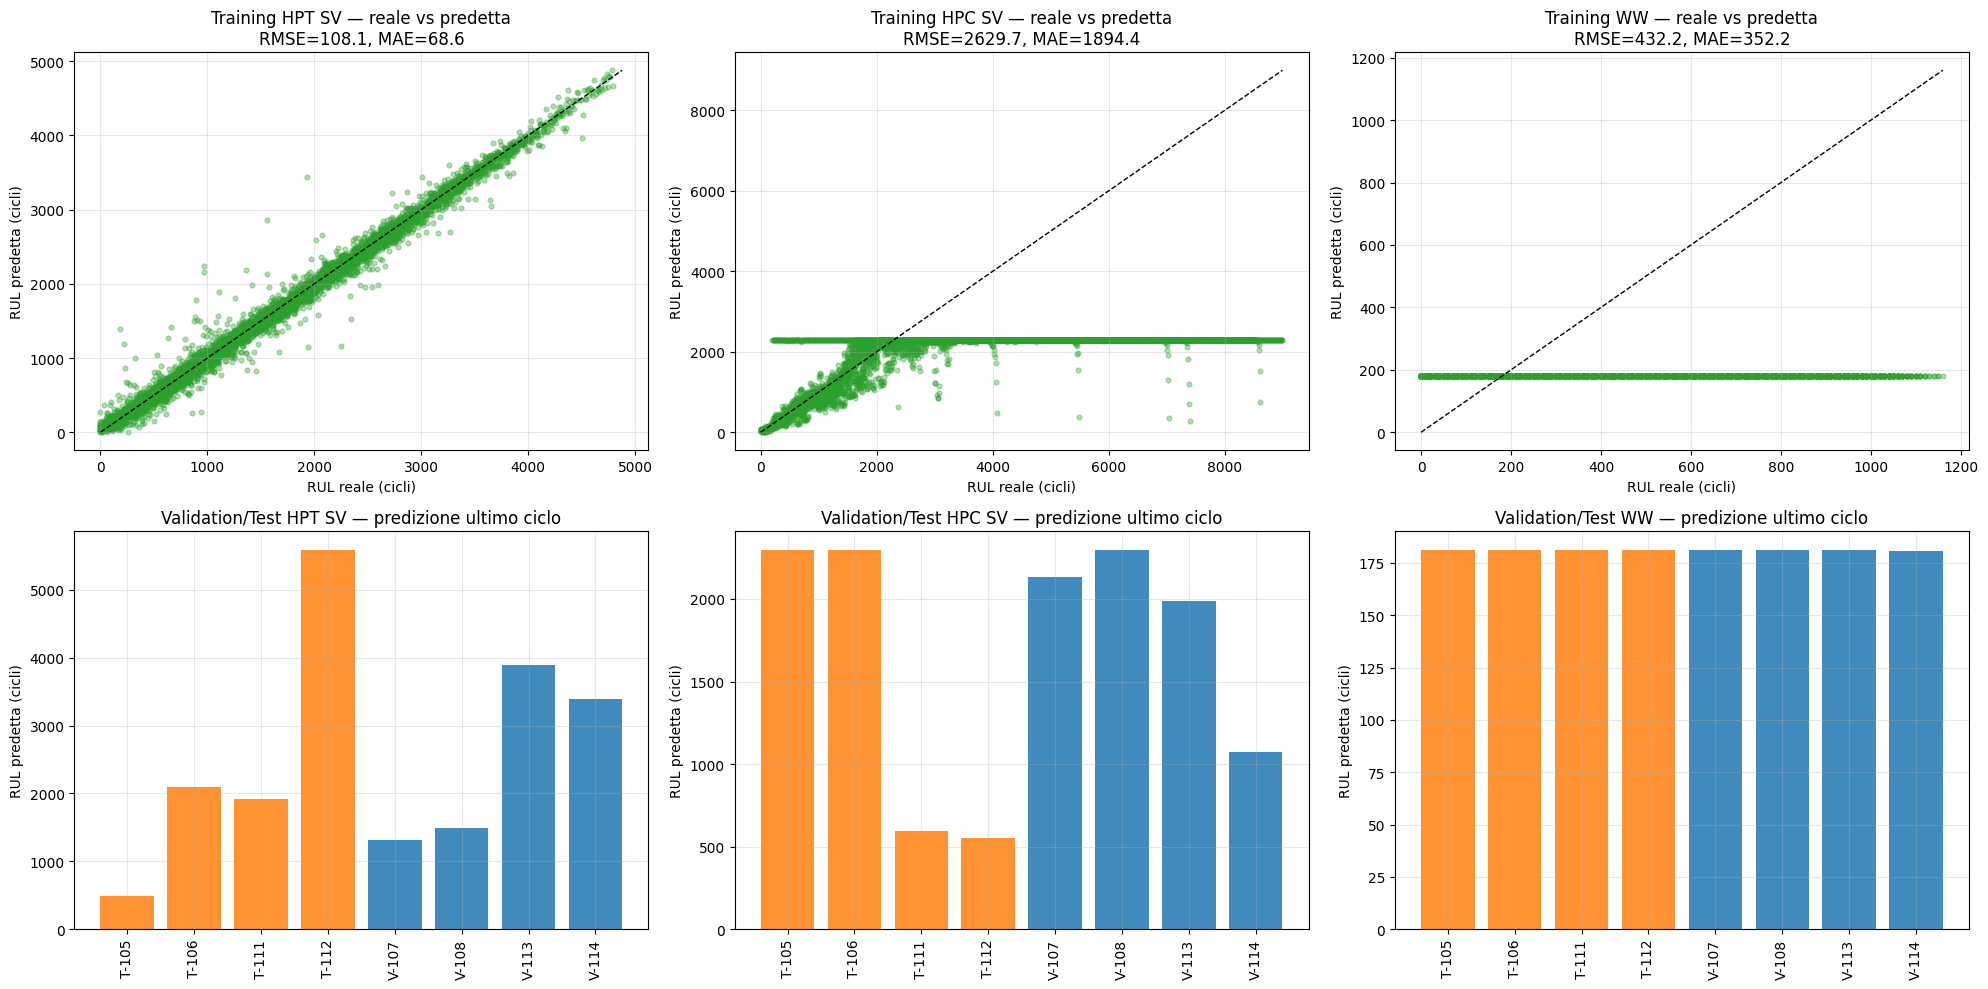

In [ ]:
required_vars = [
    "train_core",
    "hpt_ann_model",
    "model_feature_cols",
    "hpc_bundle",
    "ww_bundle",
    "final_summary",
]

missing = [v for v in required_vars if v not in globals()]
summary_ready = "final_summary" in globals() and isinstance(final_summary, pd.DataFrame) and not final_summary.empty

if not missing and summary_ready:
    train_pred_cycle = predict_events_for_cycle_df(
        cycle_df=train_core,
        hpt_model=hpt_ann_model,
        hpt_feature_cols=model_feature_cols,
        hpc_bundle=hpc_bundle,
        ww_bundle=ww_bundle,
    )

    targets = [
        ("Cycles_to_HPT_SV", "Pred_Cycles_to_HPT_SV", "HPT SV"),
        ("Cycles_to_HPC_SV", "Pred_Cycles_to_HPC_SV", "HPC SV"),
        ("Cycles_to_WW", "Pred_Cycles_to_WW", "WW"),
    ]

    p_other = final_summary.copy().sort_values(["Dataset", "ESN"]).reset_index(drop=True)
    fig, axs = plt.subplots(2, 3, figsize=(20, 10))

    for j, (true_col, pred_col, title) in enumerate(targets):
        ax_top = axs[0, j]
        comp = train_pred_cycle[[true_col, pred_col]].dropna()

        if comp.empty:
            ax_top.text(0.5, 0.5, "Dati non disponibili", ha="center", va="center")
            ax_top.set_title(f"Training {title}: confronto non disponibile")
        else:
            y_true = comp[true_col].to_numpy(dtype=float)
            y_pred = comp[pred_col].to_numpy(dtype=float)
            rmse = rmse_np(y_true, y_pred)
            mae = float(mean_absolute_error(y_true, y_pred))

            ax_top.scatter(y_true, y_pred, s=12, alpha=0.35, color="tab:green")
            low = float(np.nanmin(np.r_[y_true, y_pred]))
            high = float(np.nanmax(np.r_[y_true, y_pred]))
            ax_top.plot([low, high], [low, high], "--", color="black", linewidth=1.0)

            ax_top.set_title(f"Training {title} — reale vs predetta\nRMSE={rmse:.1f}, MAE={mae:.1f}")
            ax_top.set_xlabel("RUL reale (cicli)")
            ax_top.set_ylabel("RUL predetta (cicli)")
            ax_top.grid(True, alpha=0.3)

        ax_bottom = axs[1, j]
        ax_bottom.bar(
            np.arange(len(p_other)),
            p_other[true_col].values,
            color=["tab:blue" if d == "Validation" else "tab:orange" for d in p_other["Dataset"]],
            alpha=0.85,
        )
        ax_bottom.set_title(f"Validation/Test {title} — predizione ultimo ciclo")
        ax_bottom.set_xticks(np.arange(len(p_other)))
        ax_bottom.set_xticklabels(
            [f"{d[:1]}-{e}" for d, e in zip(p_other["Dataset"], p_other["ESN"])],
            rotation=90,
        )
        ax_bottom.set_ylabel("RUL predetta (cicli)")
        ax_bottom.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    if missing:
        print(f"Variabili mancanti: {missing}")
    if not summary_ready:
        print("final_summary non disponibile o vuoto: eseguire prima la sezione end-to-end (cella 23).")